In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = '/content/drive/MyDrive/Behavioral_analysis.csv'
print(csv_path)

/content/drive/MyDrive/Behavioral_analysis.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns: Index(['user_id', 'login_hour', 'session_duration', 'clicks', 'device_change',
       'failed_logins', 'fraud'],
      dtype='object')
Feature columns: ['login_hour', 'session_duration', 'clicks', 'device_change', 'failed_logins']
Feature count: 5
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6126 - val_accuracy: 1.0000 - val_loss: 0.6051
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5000 - loss: 0.6089 - val_accuracy: 1.0000 - val_loss: 0.6026
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5000 - loss: 0.6053 - val_accuracy: 1.0000 - val_loss: 0.6002
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5000 - loss: 0.6016 - val_accuracy: 1.0000 - val_loss: 0.5979
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5000 - loss: 0.5979 - val_accuracy: 1.0000 - val_loss: 0.5956
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - loss: 0.5942 - val_accuracy: 1.0000 - val_loss: 0.5933
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6250 - loss: 0.5905 - val_accuracy: 1.0000 - val_loss: 0.5910
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6250 - loss: 0.5868 - val_accuracy: 1.0000 - val_loss: 0.5879
Epoch 9/50
1

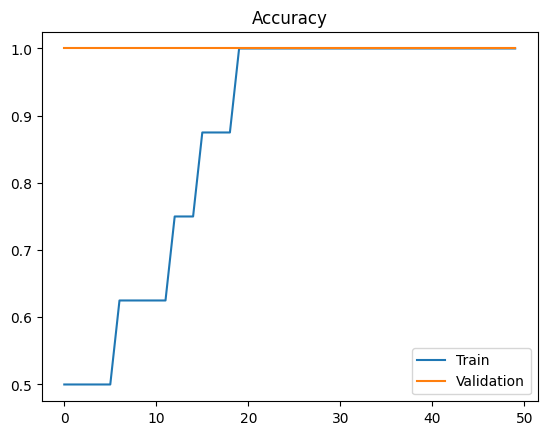

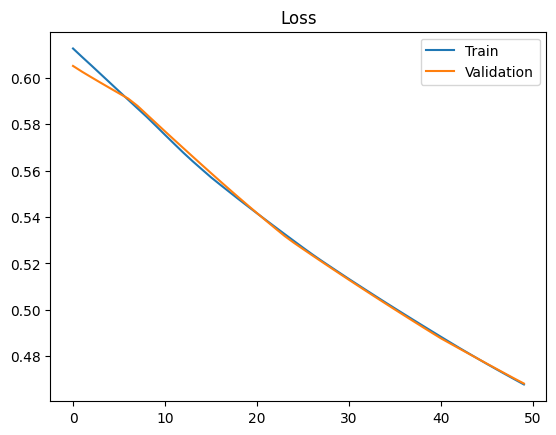

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Behavioral Fraud Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
csv_path =('/content/drive/MyDrive/Behavioral_analysis.csv/behavior_fraud_dataset.csv')
data = pd.read_csv(csv_path)

# Clean column names
data.columns = data.columns.str.strip().str.lower()
print("Columns:", data.columns)

# Drop target + optional id
drop_cols = ["fraud"]
if "user_id" in data.columns:
    drop_cols.append("user_id")

X = data.drop(drop_cols, axis=1)
y = data["fraud"]

print("Feature columns:", list(X.columns))
print("Feature count:", X.shape[1])

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

# Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()

# ---------------------------
# SAFE Prediction
# ---------------------------
# Create sample with correct feature count
sample = np.zeros((1, X.shape[1]))

# Example values (adjust if needed)
sample[0] = [2,30,4,1,5][:X.shape[1]]

sample = scaler.transform(sample)
prediction = model.predict(sample)

if prediction[0][0] > 0.5:
    print("Behavioral Fraud Detected")
else:
    print("Normal Behaviour")


In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st

st.title("Behavioral Fraud Detection")

login_hour = st.slider("Login Hour", 0, 23)
session_duration = st.number_input("Session Duration")
clicks = st.number_input("Clicks")
device_change = st.selectbox("Device Changed", [0,1])
failed_logins = st.number_input("Failed Logins")

if st.button("Analyze"):
    score = login_hour + session_duration + clicks + device_change + failed_logins

    if score > 50:
        st.error("Fraudulent Behavior Detected 🚨")
    else:
        st.success("Normal Behavior ✅")

Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501

2026-03-31T05:59:05Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-31T05:59:05Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-31T05:59:09Z INF +--------------------------------------------------------------------------------------------+
2026-03-31T05:59:09Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-31T05:59:09Z INF |  https://read-dealer-mariah-budapest.trycloudflare.com